In [27]:
ROOT_DIR = "/home/albert/Baikal2025/data_manager/"
import sys
sys.path.append(ROOT_DIR)
import os

import h5py
import uproot as ur
import numpy as np 
import awkward as ak 
import matplotlib.pyplot as plt
import pandas as pd

exp_root_dir = "/net/62/home/albert/Baikal/Data/reco_exp_root_files/"
exp_h5 = "/home/albert/Baikal2025/data_manager/data/h5datasets/exp_reco.h5"
#reco_root_dir = "/net/62/home/albert/Baikal/Data/reco_exp_root_files"

root_path_geometry = "Events/BGeomTel./BGeomTel.BGeomTel/BGeomTel.BGeomTel.fOMs/BGeomTel.BGeomTel.fOMs.fPosition"
root_pathes_data = {
    'amplitude': "Events/BEvent./BEvent.fPulses/BEvent.fPulses.fAmplitude"
    , 'time': "Events/BEvent./BEvent.fPulses/BEvent.fPulses.fTime"
    #, "Events/MCEventMask./MCEventMask.BEventMask/MCEventMask.BEventMask.fOrigins/MCEventMask.BEventMask.fOrigins.fFlag"
    , 'channel_id': "Events/BEvent./BEvent.fPulses/BEvent.fPulses.fChannelID"
}

root_files = sorted([f for f in os.listdir(exp_root_dir) if f.endswith('.root')])
root_files

['2020_cl1_run116_scl_nu_DATA2020.root',
 '2020_cl1_run188_scl_nu_DATA2020.root',
 '2020_cl1_run27_scl_nu_DATA2020.root',
 '2020_cl2_run149_scl_nu_DATA2020.root',
 '2020_cl2_run15_scl_nu_DATA2020.root',
 '2020_cl2_run206_scl_nu_DATA2020.root',
 '2020_cl2_run357_scl_nu_DATA2020.root',
 '2020_cl3_run115_scl_nu_DATA2020.root',
 '2020_cl3_run12_scl_nu_DATA2020.root',
 '2020_cl3_run263_scl_nu_DATA2020.root',
 '2020_cl3_run417_scl_nu_DATA2020.root',
 '2020_cl4_run116_scl_nu_DATA2020.root',
 '2020_cl4_run117_scl_nu_DATA2020.root',
 '2020_cl4_run37_scl_nu_DATA2020.root',
 '2020_cl5_run116_scl_nu_DATA2020.root',
 '2020_cl5_run270_scl_nu_DATA2020.root',
 '2020_cl5_run35_scl_nu_DATA2020.root',
 '2020_cl5_run377_scl_nu_DATA2020.root',
 '2020_cl6_run134_scl_nu_DATA2020.root',
 '2020_cl6_run325_scl_nu_DATA2020.root',
 '2020_cl6_run32_scl_nu_DATA2020.root',
 '2020_cl6_run413_scl_nu_DATA2020.root',
 '2020_cl7_run120_scl_nu_DATA2020.root',
 '2020_cl7_run202_scl_nu_DATA2020.root',
 '2020_cl7_run406_scl_

In [2]:
ROOT_FILE = root_files[0]
ROOT_FILE

'2020_cl1_run116_scl_nu_DATA2020.root'

# Look inside a root file

In [12]:
exp_root_path = f'{exp_root_dir}/{ROOT_FILE}'


with ur.open(exp_root_path) as rf:
    if len(rf['Events/BEvent./BEvent.fPulses/BEvent.fPulses.fChannelID'].array(library='np')[0])==0: 
        st = 1
    else: 
        st = 0
    e_channels = rf['Events/BEvent./BEvent.fPulses/BEvent.fPulses.fChannelID'].array(library='np')[st:]
    e_channels = rf['Events/BEvent./BEvent.fPulses/BEvent.fPulses.fChannelID'].array(library='np')[st:]
    root_coordinates = np.array(ak.unzip(rf[root_path_geometry].array()))[:, st:, :]
    active_clusters = [np.unique(ch // 288) for ch in e_channels]
    num_un_clusters = np.array([len(cl) for cl in active_clusters])
    
    root_data = {k: rf[p].array(library="np")[st:] for k, p in root_pathes_data.items()}
    
root_df = pd.DataFrame(root_data)

In [13]:
root_df['ordering'] = root_df['time'].apply(lambda x: x.argsort())

root_df['z'] = None
for i, row in root_df.iterrows():
    root_z = root_coordinates[2, i, row['channel_id']]
    root_df.at[i, 'z'] = root_z

In [14]:
root_df

,amplitude,time,channel_id,ordering,z
0,"[1.6370577, 1.409333, 0.79870325, 0.3257713, 0...","[12989.2, 16340.459, 15817.035, 16468.195, 180...","[4, 20, 50, 63, 63, 65, 66, 67, 68, 68, 69, 74...","[20, 32, 21, 26, 27, 23, 22, 28, 29, 30, 31, 1...","[158.57583618164062, 398.6582946777344, 308.79..."
1,"[1.5465745, 0.9504237, 0.6734655, 0.96415937, ...","[17342.37, 17564.574, 14556.031, 13954.423, 16...","[0, 1, 2, 17, 22, 26, 33, 44, 45, 54, 57, 58, ...","[48, 52, 50, 51, 49, 47, 43, 71, 29, 55, 25, 2...","[98.52672576904297, 113.53900146484375, 128.55..."
2,"[0.41635635, 1.5125604, 0.26507074, 0.34503677...","[14593.6, 13176.986, 16289.293, 17569.945, 139...","[0, 7, 8, 9, 25, 27, 33, 34, 35, 36, 36, 60, 6...","[57, 53, 55, 49, 48, 50, 54, 56, 58, 75, 18, 4...","[98.52672576904297, 203.6126708984375, 218.624..."
3,"[1.0476433, 0.5838441, 0.91032964, 1.2039692, ...","[15443.362, 16444.39, 15102.496, 15754.559, 13...","[1, 4, 5, 21, 22, 22, 24, 24, 25, 26, 26, 28, ...","[62, 58, 56, 55, 53, 54, 57, 61, 81, 20, 12, 8...","[113.53900146484375, 158.57583618164062, 173.5..."
4,"[0.54334885, 0.7977478, 1.6233519, 1.109702, 0...","[16481.674, 17326.854, 17886.842, 15302.404, 1...","[5, 16, 26, 33, 33, 35, 40, 46, 47, 60, 67, 70...","[28, 31, 27, 16, 9, 15, 44, 38, 7, 39, 50, 35,...","[173.58811950683594, 338.66302490234375, 488.6..."
...,...,...,...,...,...
27442,"[2.9072604, 1.1173126, 1.1745418, 1.7552173, 3...","[16024.789, 16317.759, 15981.432, 16043.643, 1...","[3, 3, 4, 4, 5, 7, 23, 27, 28, 32, 34, 42, 47,...","[47, 50, 73, 24, 26, 64, 10, 72, 46, 44, 59, 2...","[143.56114196777344, 143.56114196777344, 158.5..."
27443,"[1.4132472, 0.83497405, 1.113211, 5.424129, 3....","[15364.459, 16122.01, 14040.779, 15008.083, 15...","[16, 30, 34, 34, 35, 37, 59, 59, 61, 65, 65, 6...","[36, 35, 47, 14, 37, 30, 39, 2, 49, 6, 45, 16,...","[338.66522216796875, 548.6988525390625, 608.72..."
27444,"[0.91413337, 1.016823, 1.4238269, 0.3719672, 0...","[17588.09, 15237.25, 15445.073, 15305.506, 156...","[2, 7, 19, 21, 21, 23, 31, 43, 47, 49, 53, 55,...","[50, 40, 41, 42, 68, 70, 27, 51, 7, 15, 66, 44...","[128.54835510253906, 203.61224365234375, 383.6..."
27445,"[0.32507297, 0.52318776, 0.9489349, 1.1186104,...","[14312.336, 17956.98, 15336.913, 15228.734, 15...","[0, 5, 10, 11, 11, 11, 11, 12, 13, 20, 22, 26,...","[52, 60, 53, 59, 54, 55, 51, 78, 50, 65, 58, 4...","[98.52281188964844, 173.58668518066406, 248.65..."


# Look inside a corresponding h5 file

In [28]:
print(ROOT_FILE)
part_name = 'part_s2020_c01_r0116' # for 2020_cl1_run116_scl_nu_DATA2020

2020_cl1_run116_scl_nu_DATA2020.root


In [29]:
with h5py.File(exp_h5, 'r') as hf:
    group = hf['exp_reco']
    print(group['raw'].keys())
    print(group[f'raw/ev_starts'].keys())
    print(group[f'clusters_centers/{part_name}/data'][()])
    ev_starts = group[f"raw/ev_starts/{part_name}/data"][:]
    channels = group[f'raw/channels/{part_name}/data'][:]
    data = group[f'raw/data/{part_name}/data'][:]
    
    h5_data = []
    for s,e in zip(ev_starts[:-1], ev_starts[1:]):
        h5_data.append({
            'amplitude': data[s:e, 0],
            'time': data[s:e, 1],
            'z': data[s:e, 4],
            'channel_id': channels[s:e],
            'ordering': data[s:e, 1].argsort()
        })
h5_df = pd.DataFrame(h5_data)
h5_df

<KeysViewHDF5 ['channels', 'cluster_ids', 'data', 'ev_starts', 'labels', 'num_un_strings']>
<KeysViewHDF5 ['part_s2020_c01_r0027', 'part_s2020_c01_r0116', 'part_s2020_c01_r0188', 'part_s2020_c02_r0015', 'part_s2020_c02_r0149', 'part_s2020_c02_r0206', 'part_s2020_c02_r0357', 'part_s2020_c03_r0012', 'part_s2020_c03_r0115', 'part_s2020_c03_r0263', 'part_s2020_c03_r0417', 'part_s2020_c04_r0037', 'part_s2020_c04_r0116', 'part_s2020_c04_r0117', 'part_s2020_c05_r0035', 'part_s2020_c05_r0116', 'part_s2020_c05_r0270', 'part_s2020_c05_r0377', 'part_s2020_c06_r0032', 'part_s2020_c06_r0134', 'part_s2020_c06_r0325', 'part_s2020_c06_r0413', 'part_s2020_c07_r0041', 'part_s2020_c07_r0120', 'part_s2020_c07_r0202', 'part_s2020_c07_r0406']>
[[ -18.08392392 -269.75328675  361.70077024]]


,amplitude,time,z,channel_id,ordering
0,"[1.1478554, 0.81084096, 1.7453573, 1.1820323, ...","[-12114.37, -11958.917, -11873.555, -11833.389...","[-37.73547, 262.40646, 52.40311, 247.40903, 24...","[195, 215, 201, 214, 214, 202, 201, 214, 214, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,"[0.8601692, 0.6881842, 2.4497032, 0.96551657, ...","[-14369.083, -13815.001, -13807.97, -13803.031...","[-52.75854, -7.6892653, -37.73547, -22.712366,...","[194, 197, 195, 196, 194, 192, 185, 274, 114, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
2,"[25.258352, 8.623985, 16.864992, 0.5691146, 1....","[-13446.992, -13438.983, -13424.666, -13399.10...","[262.40634, 232.41153, 247.4089, 82.44929, 7.3...","[215, 213, 214, 203, 198, 203, 213, 214, 215, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
3,"[0.6959019, 1.7869176, 1.6832695, 1.0498314, 1...","[-13996.847, -13749.252, -13746.059, -13744.38...","[262.40634, 82.44929, 52.40311, 37.38001, -22....","[215, 203, 201, 200, 196, 199, 202, 211, 257, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
4,"[0.98444813, 0.51180834, 0.9113542, 1.2468083,...","[-14090.854, -13802.892, -13628.136, -1557.455...","[-7.6892653, 202.41666, -52.75854, 262.12564, ...","[197, 211, 194, 107, 60, 105, 279, 252, 46, 25...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
...,...,...,...,...,...
27442,"[1.8902019, 0.7763704, 0.22887574, 1.292083, 1...","[-14537.292, -14419.646, -2534.256, -2229.9211...","[52.405674, 262.43765, 27.227148, -113.42861, ...","[201, 215, 271, 82, 96, 254, 34, 270, 183, 135...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
27443,"[1.1416686, 1.4072697, 0.89096653, 1.1052257, ...","[-14699.502, -14168.285, -1816.5854, -1525.267...","[262.43765, 52.405674, 117.895424, 232.50967, ...","[215, 201, 277, 69, 217, 120, 237, 34, 281, 59...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
27444,"[0.74329054, 1.1030024, 5.40204, 0.7068531, 0....","[-14260.806, -14150.288, -14033.97, -14028.549...","[202.43875, -7.687007, -7.687007, 22.35932, 19...","[211, 197, 197, 199, 282, 284, 101, 219, 43, 5...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
27445,"[1.2292523, 1.1373241, 0.5679525, 0.7465468, 0...","[-14067.822, -13996.372, -13745.925, -13591.65...","[52.405674, 232.4382, 52.405674, 202.43875, 67...","[201, 213, 201, 211, 202, 202, 200, 277, 191, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


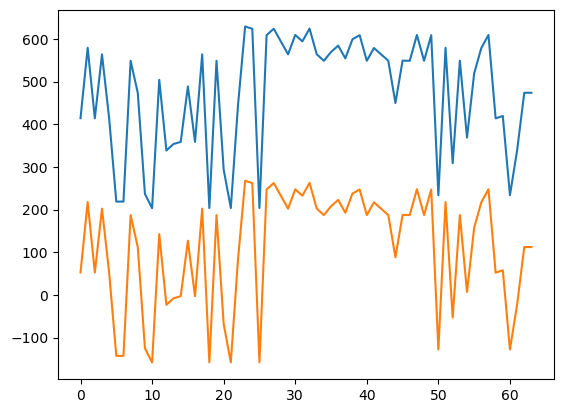

In [22]:
index = 100

z_root_event = root_df['z'].iloc[index][root_df['ordering'].iloc[index]]
z_h5_event = h5_df['z'].iloc[index]

plt.plot(z_root_event)
plt.plot(z_h5_event)